Kütüphaneler başarıyla yüklendi.
Veriler yükleniyor...
Veri ön işleme tamamlandı.


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 195ms/step - acc: 0.6057 - loss: 0.6477 - val_acc: 0.7438 - val_loss: 0.5225
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 201ms/step - acc: 0.8006 - loss: 0.4484 - val_acc: 0.8052 - val_loss: 0.4636
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 192ms/step - acc: 0.8519 - loss: 0.3520 - val_acc: 0.8230 - val_loss: 0.4435
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 192ms/step - acc: 0.8911 - loss: 0.2677 - val_acc: 0.7830 - val_loss: 0.4808
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 193ms/step - acc: 0.9263 - loss: 0.1936 - val_acc: 0.8418 - val_loss: 0.4211


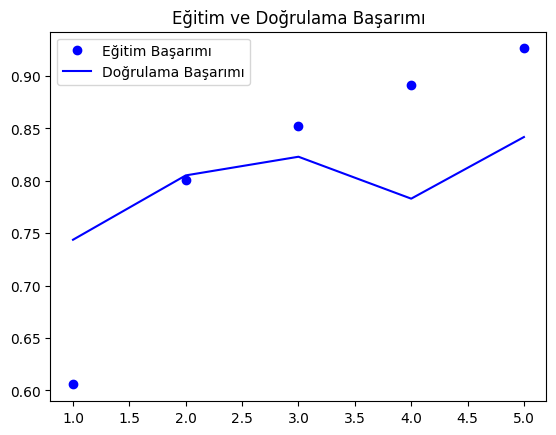

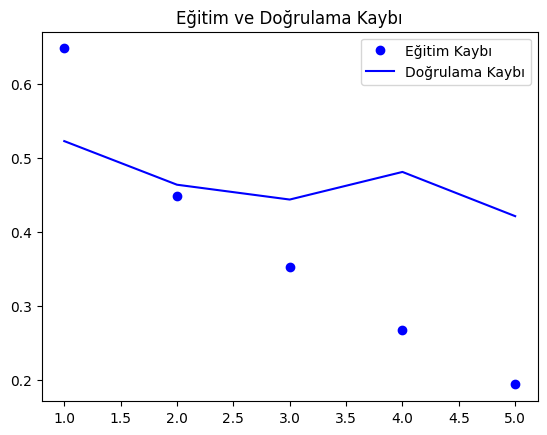

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

print("Kütüphaneler başarıyla yüklendi.")
max_features = 10000  # En sık kullanılan 10.000 kelime
maxlen = 500         # Cümle boyutu sabitleme

print("Veriler yükleniyor...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# Padding işlemi: Kısa cümleleri doldurur, uzunları keser
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)

print("Veri ön işleme tamamlandı.")
model = Sequential()
model.add(Embedding(max_features, 32))
model.add(SimpleRNN(32)) # Ana RNN katmanı
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
model.summary() # Modelin yapısını yazdırır
history = model.fit(x_train, y_train,
                    epochs=5,
                    batch_size=128,
                    validation_split=0.2)
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Eğitim Başarımı')
plt.plot(epochs, val_acc, 'b', label='Doğrulama Başarımı')
plt.title('Eğitim ve Doğrulama Başarımı')
plt.legend()

plt.figure()
plt.plot(epochs, loss, 'bo', label='Eğitim Kaybı')
plt.plot(epochs, val_loss, 'b', label='Doğrulama Kaybı')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.legend()
plt.show()

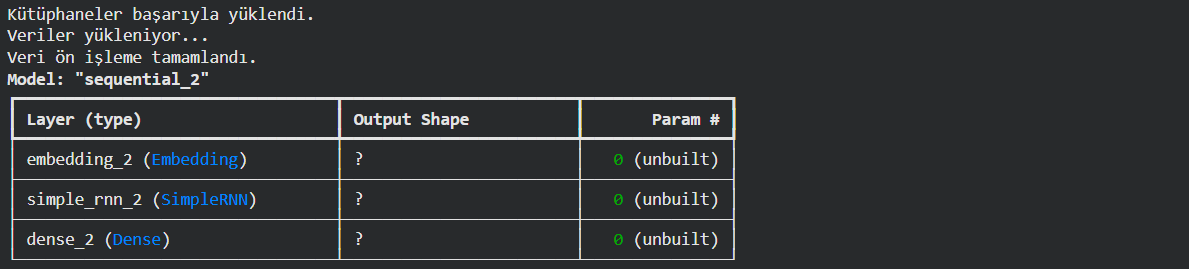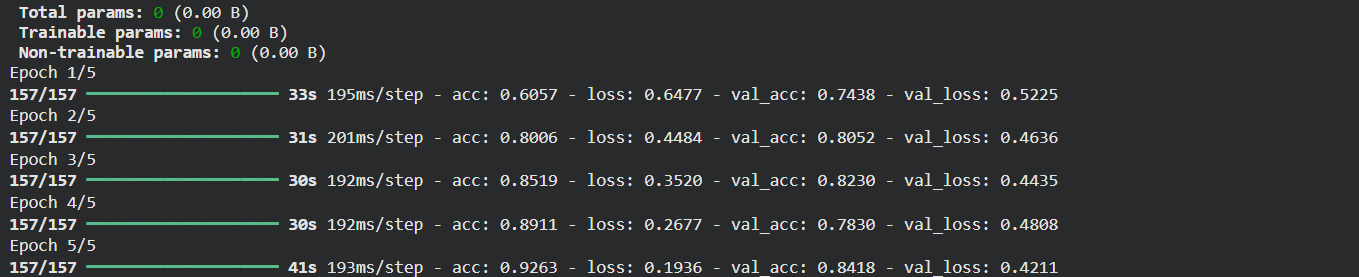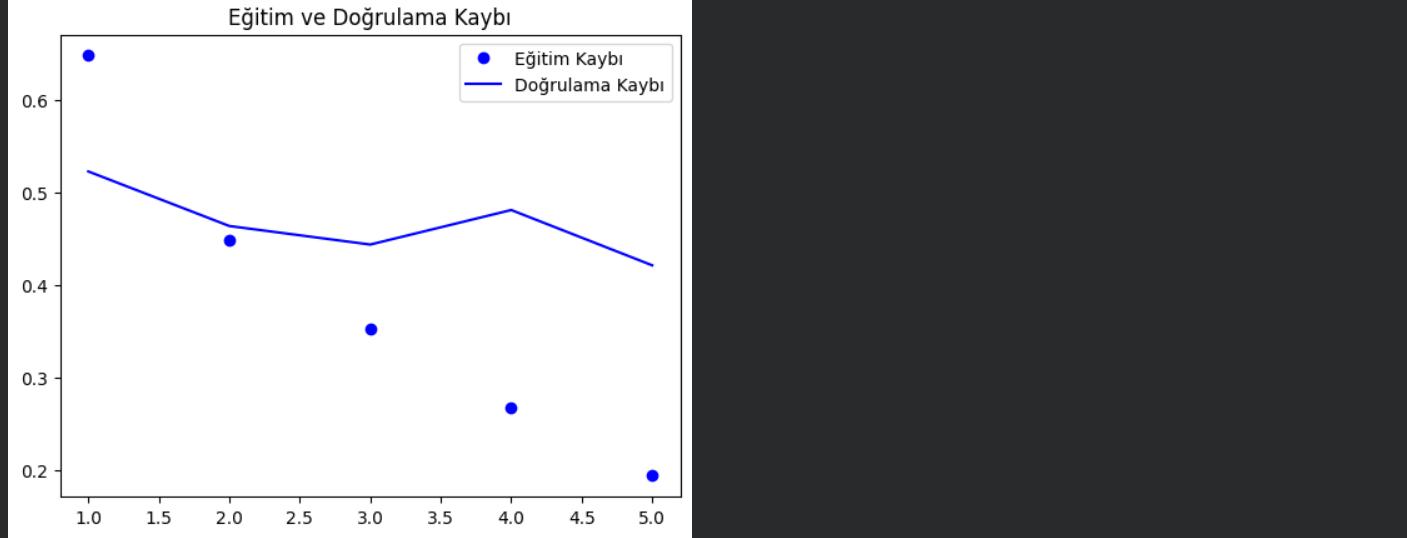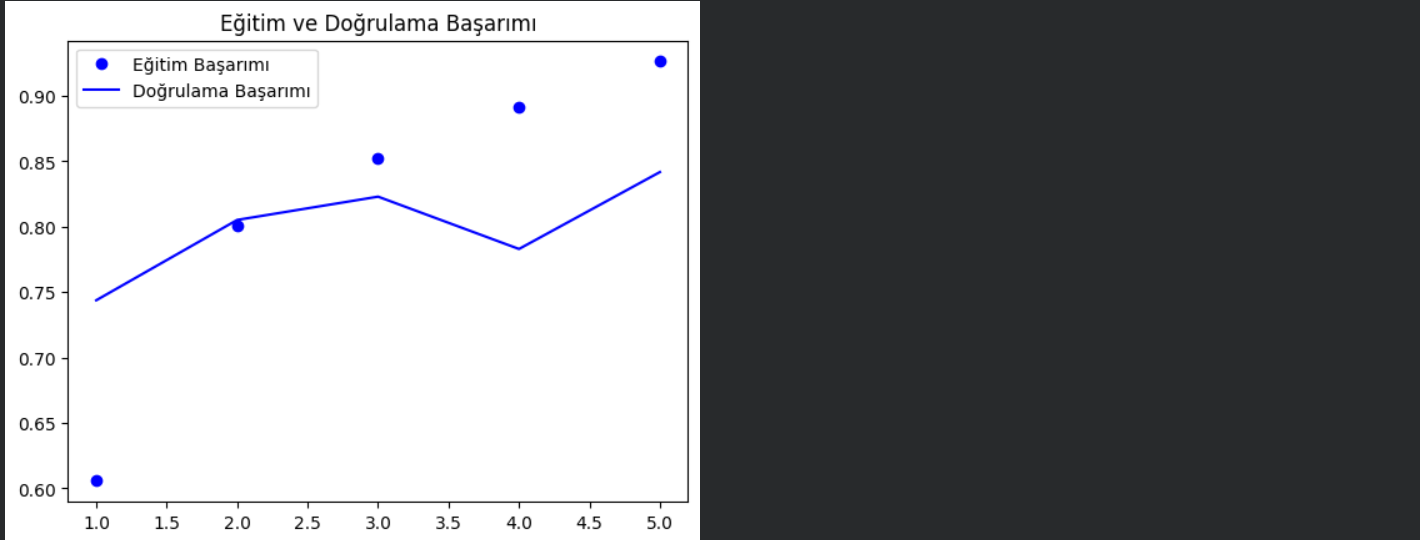